## DESCARGAR 1ER SUJETO

In [1]:
from nilearn import datasets

abide = datasets.fetch_abide_pcp(
    data_dir="./data",
    n_subjects=1,
    pipeline="cpac",
    band_pass_filtering=False,
    global_signal_regression=False,
    derivatives=["func_preproc"]
)

In [2]:
print(abide.keys())

dict_keys(['description', 'phenotypic', 'func_preproc'])


In [3]:
print(abide.func_preproc)

['./data\\ABIDE_pcp\\cpac\\nofilt_noglobal\\Pitt_0050003_func_preproc.nii.gz']


In [4]:
fmri_path = abide.func_preproc[0]
print(fmri_path)

./data\ABIDE_pcp\cpac\nofilt_noglobal\Pitt_0050003_func_preproc.nii.gz


In [5]:
import nibabel as nib

img = nib.load(fmri_path)
data = img.get_fdata()

print("Shape:", data.shape)

Shape: (61, 73, 61, 196)


## 4D

In [6]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

fmri_path = abide.func_preproc[0]

img = nib.load(fmri_path)
data = img.get_fdata()

print("Shape del volumen:", data.shape)
print("Número de dimensiones:", data.ndim)
print("Tipo:", type(data))

Shape del volumen: (61, 73, 61, 196)
Número de dimensiones: 4
Tipo: <class 'numpy.ndarray'>


In [7]:
x_dim, y_dim, z_dim, t_dim = data.shape

print(f"Dimensión X: {x_dim}")
print(f"Dimensión Y: {y_dim}")
print(f"Dimensión Z: {z_dim}")
print(f"Timepoints: {t_dim}")

Dimensión X: 61
Dimensión Y: 73
Dimensión Z: 61
Timepoints: 196


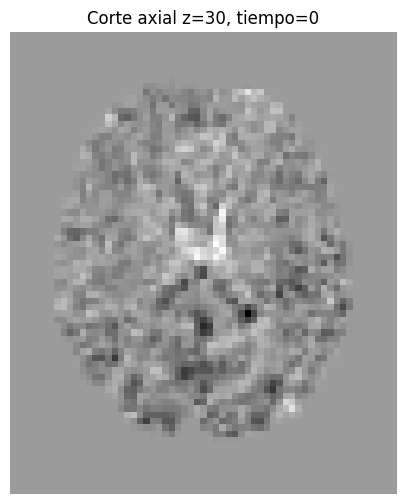

In [8]:
z = z_dim // 2

plt.figure(figsize=(6, 6))
plt.imshow(data[:, :, z, 0].T, cmap="gray", origin="lower")
plt.title(f"Corte axial z={z}, tiempo=0")
plt.axis("off")
plt.show()

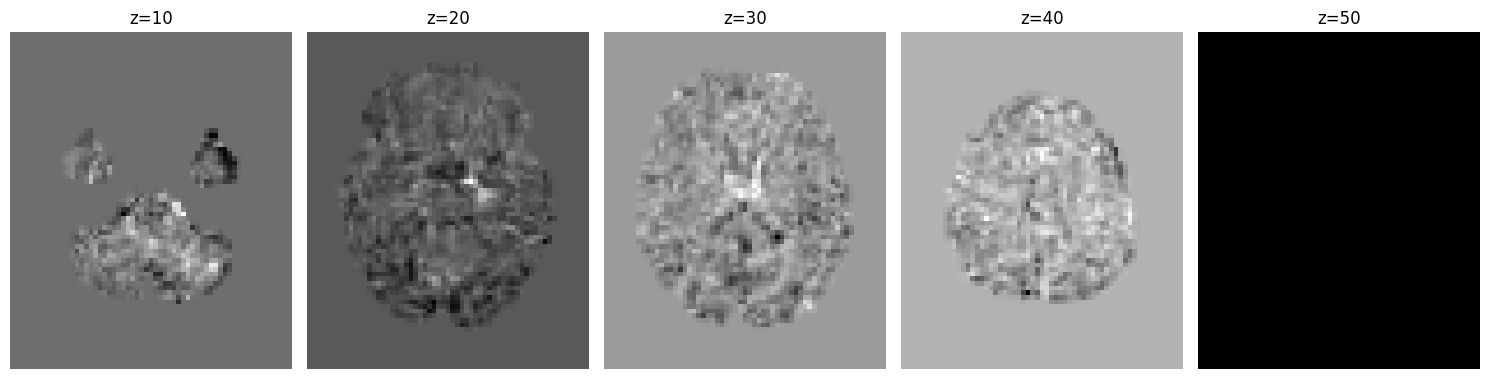

In [9]:
slices = [10, 20, 30, 40, 50]

fig, axes = plt.subplots(1, len(slices), figsize=(15, 4))

for ax, z in zip(axes, slices):
    if z < z_dim:
        ax.imshow(data[:, :, z, 0].T, cmap="gray", origin="lower")
        ax.set_title(f"z={z}")
        ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
x = x_dim // 2
y = y_dim // 2
z = z_dim // 2

signal = data[x, y, z, :]

print("Largo de la señal:", len(signal))
print("Primeros 10 valores:")
print(signal[:10])

Largo de la señal: 196
Primeros 10 valores:
[ 15.4220426  -48.03869064 110.42695792 102.03827326 161.07197658
 122.34468818 -12.94478029  47.1026526   93.25915256  76.22823664]


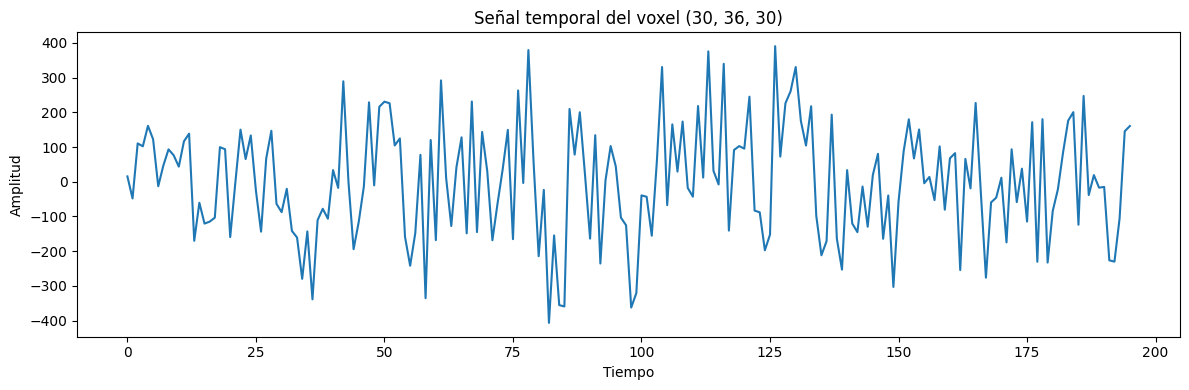

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(signal)
plt.title(f"Señal temporal del voxel ({x}, {y}, {z})")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.tight_layout()
plt.show()

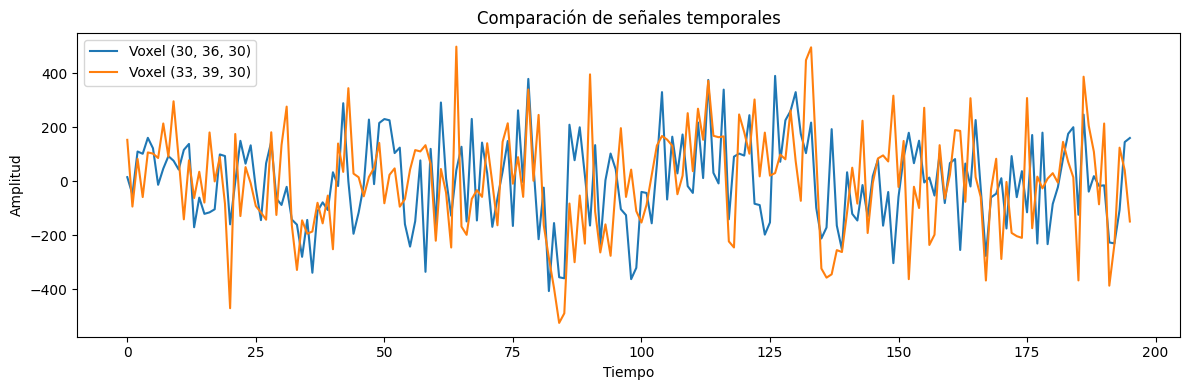

In [12]:
x1, y1, z1 = x_dim // 2, y_dim // 2, z_dim // 2
x2, y2, z2 = x_dim // 2 + 3, y_dim // 2 + 3, z_dim // 2

signal1 = data[x1, y1, z1, :]
signal2 = data[x2, y2, z2, :]

plt.figure(figsize=(12, 4))
plt.plot(signal1, label=f"Voxel ({x1}, {y1}, {z1})")
plt.plot(signal2, label=f"Voxel ({x2}, {y2}, {z2})")
plt.title("Comparación de señales temporales")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
corr = np.corrcoef(signal1, signal2)[0, 1]
print("Correlación entre ambos voxeles:", corr)

Correlación entre ambos voxeles: 0.3188608275277598


## CORTES

In [14]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [15]:
from nilearn import datasets

abide = datasets.fetch_abide_pcp(
    data_dir="./data",
    n_subjects=1,
    pipeline="cpac",
    band_pass_filtering=False,
    global_signal_regression=False,
    derivatives=["func_preproc"]
)

fmri_path = abide.func_preproc[0]

img = nib.load(fmri_path)
data = img.get_fdata()

print("Shape:", data.shape)

Shape: (61, 73, 61, 196)


In [16]:
x_dim, y_dim, z_dim, t_dim = data.shape

print(f"X: {x_dim}")
print(f"Y: {y_dim}")
print(f"Z: {z_dim}")
print(f"T: {t_dim}")

X: 61
Y: 73
Z: 61
T: 196


In [17]:
def mostrar_corte_axial(z, t=0):
    plt.figure(figsize=(6, 6))
    plt.imshow(data[:, :, z, t].T, cmap="gray", origin="lower")
    plt.title(f"Corte axial z={z}, tiempo={t}")
    plt.axis("off")
    plt.show()

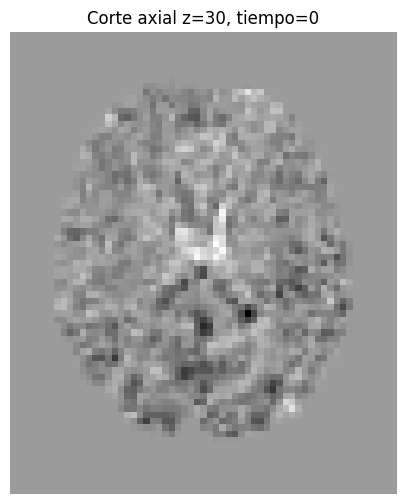

In [18]:
mostrar_corte_axial(z_dim // 2, 0)

In [19]:
slider_z = widgets.IntSlider(
    value=z_dim // 2,
    min=0,
    max=z_dim - 1,
    step=1,
    description='Slice z:'
)

widgets.interact(mostrar_corte_axial, z=slider_z, t=widgets.fixed(0))

interactive(children=(IntSlider(value=30, description='Slice z:', max=60), Output()), _dom_classes=('widget-in…

<function __main__.mostrar_corte_axial(z, t=0)>

In [20]:
slider_t = widgets.IntSlider(
    value=0,
    min=0,
    max=t_dim - 1,
    step=1,
    description='Tiempo:'
)

widgets.interact(mostrar_corte_axial, z=slider_z, t=slider_t)

interactive(children=(IntSlider(value=30, description='Slice z:', max=60), IntSlider(value=0, description='Tie…

<function __main__.mostrar_corte_axial(z, t=0)>

In [21]:
def visor_axial(z, t):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(data[:, :, z, t].T, cmap="gray", origin="lower")
    ax.set_title(f"Corte axial z={z}, tiempo={t}")
    ax.axis("off")
    plt.show()

widgets.interact(
    visor_axial,
    z=widgets.IntSlider(value=z_dim // 2, min=0, max=z_dim - 1, step=1, description="z"),
    t=widgets.IntSlider(value=0, min=0, max=t_dim - 1, step=1, description="t")
)

interactive(children=(IntSlider(value=30, description='z', max=60), IntSlider(value=0, description='t', max=19…

<function __main__.visor_axial(z, t)>

## SEÑAL


In [22]:
!pip install ipympl
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from nilearn import datasets
%matplotlib widget


In [23]:
abide = datasets.fetch_abide_pcp(
    data_dir="./data",
    n_subjects=1,
    pipeline="cpac",
    band_pass_filtering=False,
    global_signal_regression=False,
    derivatives=["func_preproc"]
)

fmri_path = abide.func_preproc[0]

img = nib.load(fmri_path)
data = img.get_fdata()

print("Ruta:", fmri_path)
print("Shape:", data.shape)

Ruta: ./data\ABIDE_pcp\cpac\nofilt_noglobal\Pitt_0050003_func_preproc.nii.gz
Shape: (61, 73, 61, 196)


In [24]:
x_dim, y_dim, z_dim, t_dim = data.shape

print(f"X: {x_dim}")
print(f"Y: {y_dim}")
print(f"Z: {z_dim}")
print(f"T: {t_dim}")

X: 61
Y: 73
Z: 61
T: 196


In [25]:
z_actual = z_dim // 2
t_actual = 0

In [26]:
def mostrar_corte_y_senal(z, t=0):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(data[:, :, z, t].T, cmap="gray", origin="lower")
    axes[0].set_title(f"Corte axial z={z}, tiempo={t}")
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")

    axes[1].set_title("Haz clic en la imagen")
    axes[1].set_xlabel("Tiempo")
    axes[1].set_ylabel("Amplitud")

    def onclick(event):
        if event.inaxes == axes[0] and event.xdata is not None and event.ydata is not None:
            x = int(round(event.xdata))
            y = int(round(event.ydata))

            if 0 <= x < x_dim and 0 <= y < y_dim:
                signal = data[x, y, z, :]

                axes[1].cla()
                axes[1].plot(signal)
                axes[1].set_title(f"Señal temporal voxel ({x}, {y}, {z})")
                axes[1].set_xlabel("Tiempo")
                axes[1].set_ylabel("Amplitud")

                axes[0].cla()
                axes[0].imshow(data[:, :, z, t].T, cmap="gray", origin="lower")
                axes[0].scatter(x, y, c="red", s=50)
                axes[0].set_title(f"Corte axial z={z}, tiempo={t}")
                axes[0].set_xlabel("X")
                axes[0].set_ylabel("Y")

                fig.canvas.draw()

                print(f"Voxel seleccionado: x={x}, y={y}, z={z}")

    fig.canvas.mpl_connect("button_press_event", onclick)
    plt.tight_layout()
    plt.show()

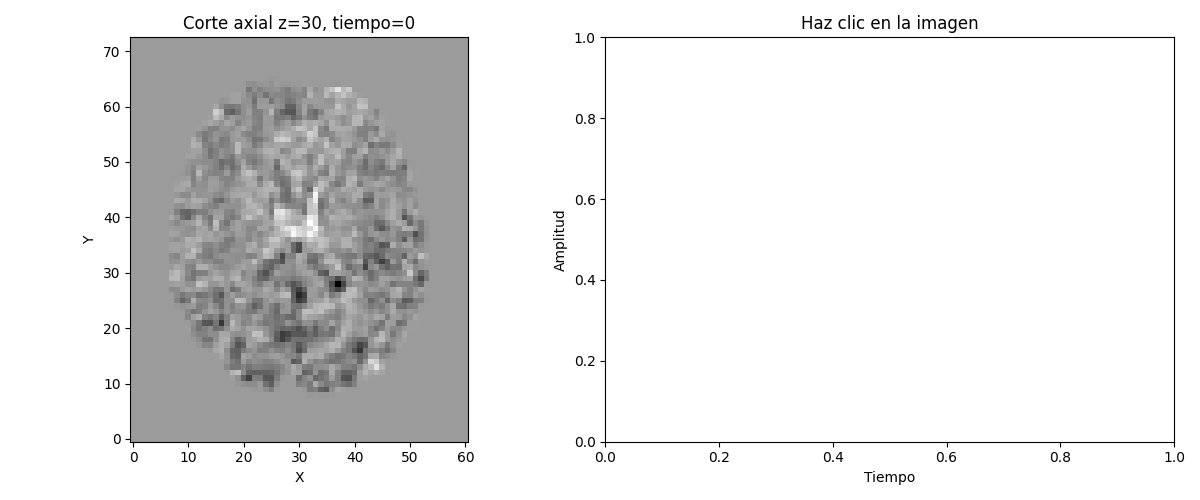

In [27]:
mostrar_corte_y_senal(z=z_dim // 2, t=0)

In [28]:
widgets.interact(
    mostrar_corte_y_senal,
    z=widgets.IntSlider(value=z_dim // 2, min=0, max=z_dim - 1, step=1, description="z"),
    t=widgets.fixed(0)
)

interactive(children=(IntSlider(value=30, description='z', max=60), Output()), _dom_classes=('widget-interact'…

<function __main__.mostrar_corte_y_senal(z, t=0)>

In [29]:
widgets.interact(
    mostrar_corte_y_senal,
    z=widgets.IntSlider(value=z_dim // 2, min=0, max=z_dim - 1, step=1, description="z"),
    t=widgets.IntSlider(value=0, min=0, max=t_dim - 1, step=1, description="t")
)

interactive(children=(IntSlider(value=30, description='z', max=60), IntSlider(value=0, description='t', max=19…

<function __main__.mostrar_corte_y_senal(z, t=0)>

## Mapa de correlacion


In [30]:
%matplotlib widget

In [31]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

from nilearn import datasets

In [32]:
abide = datasets.fetch_abide_pcp(
    data_dir="./data",
    n_subjects=1,
    pipeline="cpac",
    band_pass_filtering=False,
    global_signal_regression=False,
    derivatives=["func_preproc"]
)

fmri_path = abide.func_preproc[0]

img = nib.load(fmri_path)
data = img.get_fdata()

print("Ruta:", fmri_path)
print("Shape:", data.shape)

Ruta: ./data\ABIDE_pcp\cpac\nofilt_noglobal\Pitt_0050003_func_preproc.nii.gz
Shape: (61, 73, 61, 196)


In [33]:
x_dim, y_dim, z_dim, t_dim = data.shape

print(f"X: {x_dim}")
print(f"Y: {y_dim}")
print(f"Z: {z_dim}")
print(f"T: {t_dim}")

X: 61
Y: 73
Z: 61
T: 196


In [34]:
def correlacion_segura(signal1, signal2):
    if np.std(signal1) == 0 or np.std(signal2) == 0:
        return 0
    return np.corrcoef(signal1, signal2)[0, 1]

In [35]:
def calcular_mapa_correlacion(data, x_seed, y_seed, z):
    seed_signal = data[x_seed, y_seed, z, :]
    corr_map = np.zeros((x_dim, y_dim))

    for i in range(x_dim):
        for j in range(y_dim):
            voxel_signal = data[i, j, z, :]
            corr_map[i, j] = correlacion_segura(seed_signal, voxel_signal)

    return corr_map, seed_signal

In [36]:
x_seed = x_dim // 2
y_seed = y_dim // 2
z = z_dim // 2

corr_map, seed_signal = calcular_mapa_correlacion(data, x_seed, y_seed, z)

print("Shape del mapa:", corr_map.shape)

Shape del mapa: (61, 73)


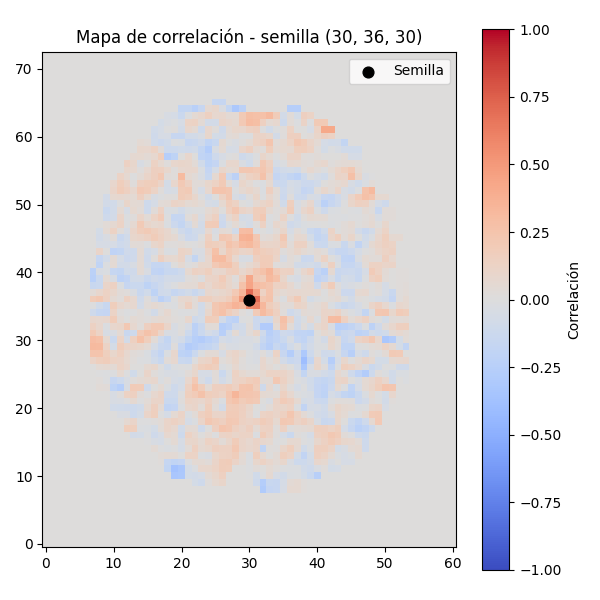

In [37]:
plt.figure(figsize=(6, 6))
plt.imshow(corr_map.T, cmap="coolwarm", origin="lower", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")
plt.scatter(x_seed, y_seed, c="black", s=60, label="Semilla")
plt.title(f"Mapa de correlación - semilla ({x_seed}, {y_seed}, {z})")
plt.legend()
plt.tight_layout()
plt.show()

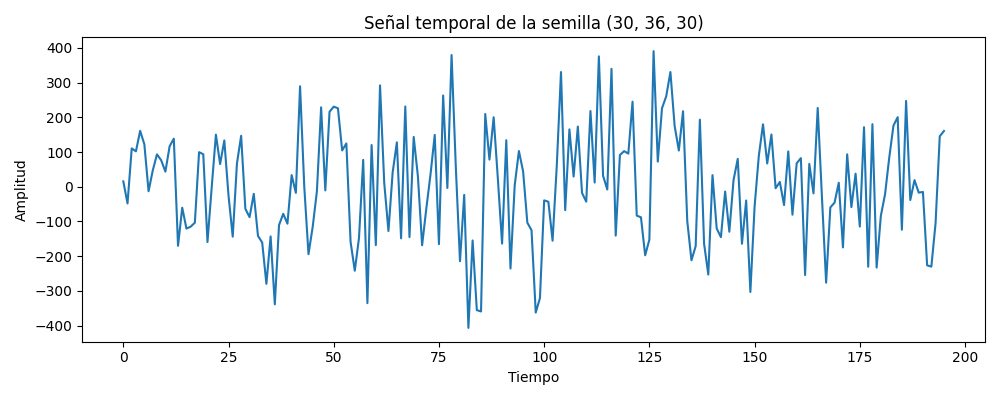

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(seed_signal)
plt.title(f"Señal temporal de la semilla ({x_seed}, {y_seed}, {z})")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.tight_layout()
plt.show()

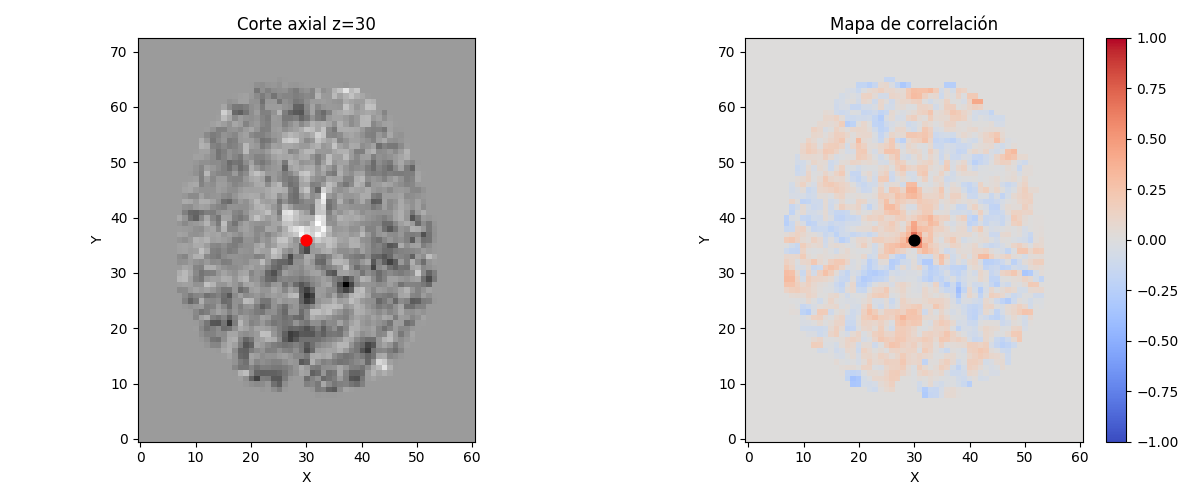

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(data[:, :, z, 0].T, cmap="gray", origin="lower")
axes[0].scatter(x_seed, y_seed, c="red", s=60)
axes[0].set_title(f"Corte axial z={z}")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

im = axes[1].imshow(corr_map.T, cmap="coolwarm", origin="lower", vmin=-1, vmax=1)
axes[1].scatter(x_seed, y_seed, c="black", s=60)
axes[1].set_title("Mapa de correlación")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [43]:
def mostrar_mapa_interactivo(z, t=0):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Imagen inicial corte axial
    axes[0].imshow(data[:, :, z, t].T, cmap="gray", origin="lower")
    axes[0].set_title(f"Corte axial z={z}, tiempo={t}")
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")

    # Imagen inicial vacía para el mapa
    mapa_inicial = np.zeros((x_dim, y_dim))
    im = axes[1].imshow(mapa_inicial.T, cmap="coolwarm", origin="lower", vmin=-1, vmax=1)
    axes[1].set_title("Haz clic en la imagen")
    axes[1].set_xlabel("X")
    axes[1].set_ylabel("Y")

    # Crear colorbar UNA sola vez
    cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label("Correlación")

    def onclick(event):
        if event.inaxes == axes[0] and event.xdata is not None and event.ydata is not None:
            x_seed = int(round(event.xdata))
            y_seed = int(round(event.ydata))

            if 0 <= x_seed < x_dim and 0 <= y_seed < y_dim:
                corr_map, seed_signal = calcular_mapa_correlacion(data, x_seed, y_seed, z)

                # Actualizar corte axial
                axes[0].cla()
                axes[0].imshow(data[:, :, z, t].T, cmap="gray", origin="lower")
                axes[0].scatter(x_seed, y_seed, c="red", s=60)
                axes[0].set_title(f"Corte axial z={z}, tiempo={t}")
                axes[0].set_xlabel("X")
                axes[0].set_ylabel("Y")

                # Actualizar mapa SIN crear otra colorbar
                axes[1].cla()
                im2 = axes[1].imshow(corr_map.T, cmap="coolwarm", origin="lower", vmin=-1, vmax=1)
                axes[1].scatter(x_seed, y_seed, c="black", s=60)
                axes[1].set_title(f"Mapa de correlación\nSemilla ({x_seed}, {y_seed}, {z})")
                axes[1].set_xlabel("X")
                axes[1].set_ylabel("Y")

                # actualizar la colorbar existente
                cbar.update_normal(im2)

                fig.canvas.draw_idle()

                print(f"Semilla seleccionada: ({x_seed}, {y_seed}, {z})")

    fig.canvas.mpl_connect("button_press_event", onclick)
    plt.tight_layout()
    plt.show()

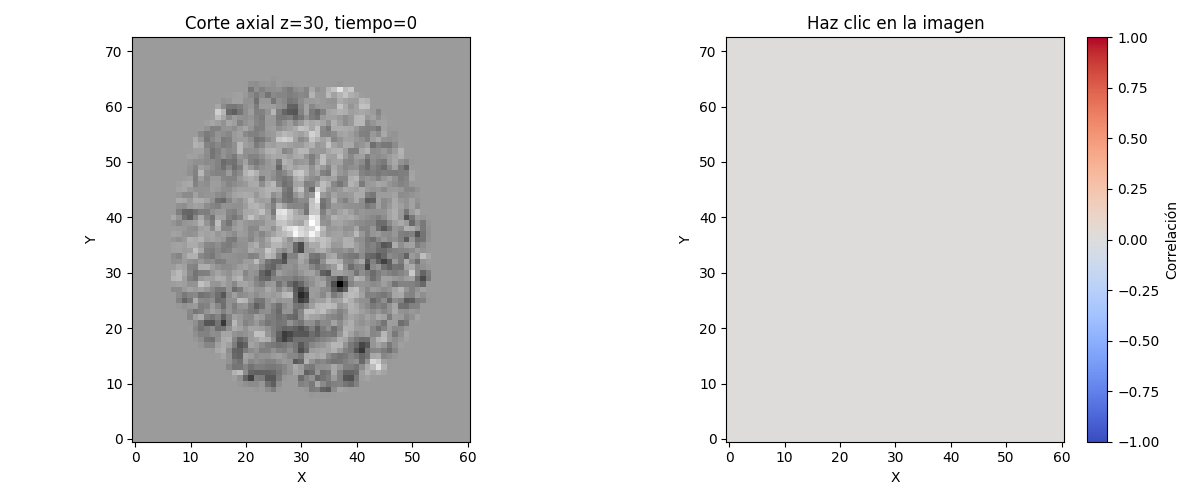

In [44]:
mostrar_mapa_interactivo(z=z_dim // 2, t=0)

In [ ]:
widgets.interact(
    mostrar_mapa_interactivo,
    z=widgets.IntSlider(value=z_dim // 2, min=0, max=z_dim - 1, step=1, description="z"),
    t=widgets.fixed(0)
)

interactive(children=(IntSlider(value=30, description='z', max=60), Output()), _dom_classes=('widget-interact'…

<function __main__.mostrar_mapa_interactivo(z, t=0)>

## PARCELACIÓN

In [46]:
%matplotlib widget

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

from nilearn import datasets
from nilearn.image import resample_to_img

In [48]:
abide = datasets.fetch_abide_pcp(
    data_dir="./data",
    n_subjects=1,
    pipeline="cpac",
    band_pass_filtering=False,
    global_signal_regression=False,
    derivatives=["func_preproc"]
)

fmri_path = abide.func_preproc[0]

fmri_img = nib.load(fmri_path)
fmri_data = fmri_img.get_fdata()

print("fMRI shape:", fmri_data.shape)

fMRI shape: (61, 73, 61, 196)


In [50]:
atlas = datasets.fetch_atlas_harvard_oxford(
    'cort-maxprob-thr25-2mm'
)
print(atlas.keys())
print(atlas.maps)
print(len(atlas.labels))

dict_keys(['filename', 'maps', 'labels', 'description'])

<class 'nibabel.nifti1.Nifti1Image'>
data shape (91, 109, 91)
affine:
[[   2.    0.    0.  -90.]
 [   0.    2.    0. -126.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  3  91 109  91   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 2. 2. 2. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 0
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        :

In [52]:
atlas_img = atlas.maps
atlas_data = atlas_img.get_fdata()

print("Atlas shape:", atlas_data.shape)

Atlas shape: (91, 109, 91)


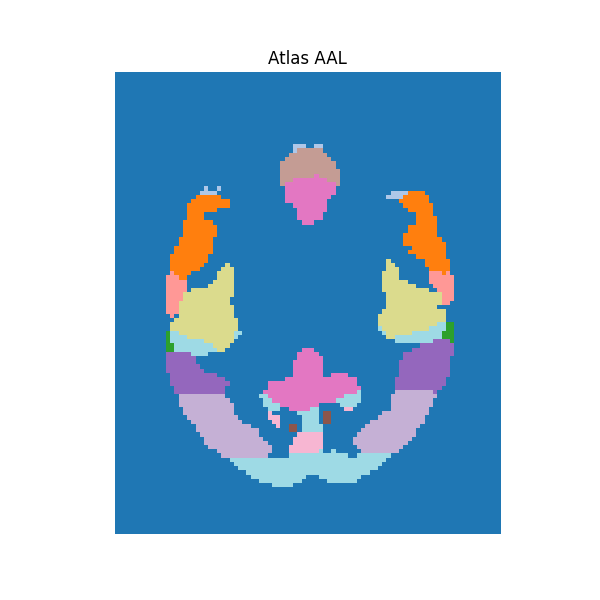

In [53]:
z = atlas_data.shape[2] // 2

plt.figure(figsize=(6,6))
plt.imshow(atlas_data[:, :, z].T, cmap="tab20", origin="lower")
plt.title("Atlas AAL")
plt.axis("off")
plt.show()

In [54]:
atlas_resampled = resample_to_img(
    atlas_img,
    fmri_img.slicer[:, :, :, 0],
    interpolation="nearest"
)

atlas_resampled_data = atlas_resampled.get_fdata()

print("Nuevo atlas shape:", atlas_resampled_data.shape)

Nuevo atlas shape: (61, 73, 61)


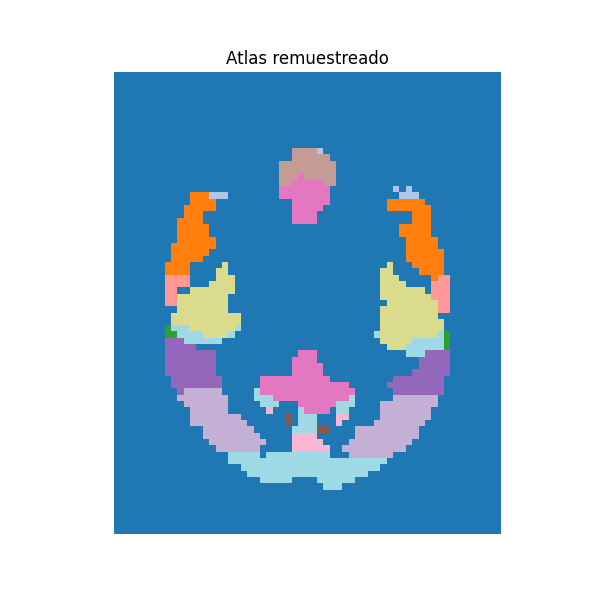

In [55]:
z = atlas_resampled_data.shape[2] // 2

plt.figure(figsize=(6,6))
plt.imshow(atlas_resampled_data[:, :, z].T, cmap="tab20", origin="lower")
plt.title("Atlas remuestreado")
plt.axis("off")
plt.show()

In [56]:
ids = np.unique(atlas_resampled_data)

print("IDs regiones:")
print(ids[:20])
print("Total IDs:", len(ids))

IDs regiones:
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19.]
Total IDs: 49


In [57]:
roi_id = 1   # prueba

mask = atlas_resampled_data == roi_id

print("Voxeles ROI:", np.sum(mask))

Voxeles ROI: 4546


In [58]:
# promedio espacial para cada tiempo
roi_signal = fmri_data[mask, :].mean(axis=0)

print("Shape señal ROI:", roi_signal.shape)

Shape señal ROI: (196,)


C:\Users\crist\AppData\Local\Temp\ipykernel_26976\3018853862.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,4))


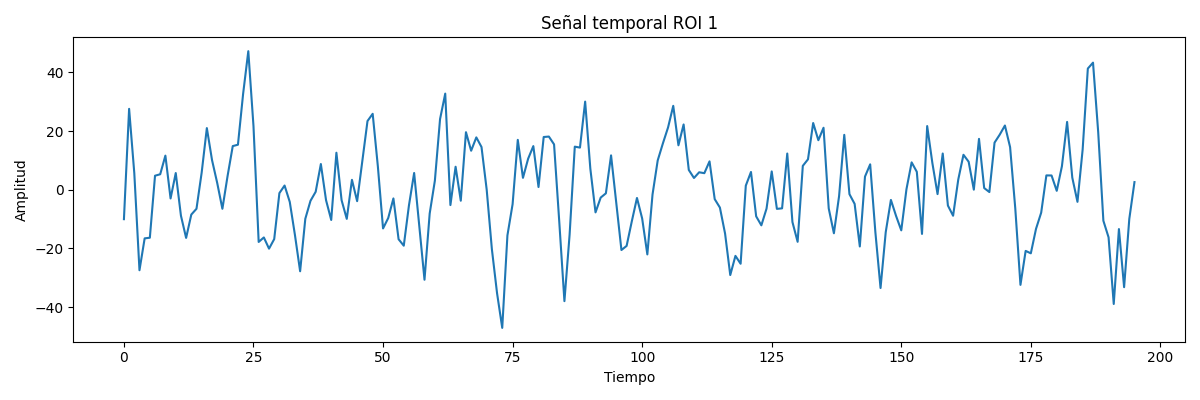

In [59]:
plt.figure(figsize=(12,4))
plt.plot(roi_signal)
plt.title(f"Señal temporal ROI {roi_id}")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.tight_layout()
plt.show()

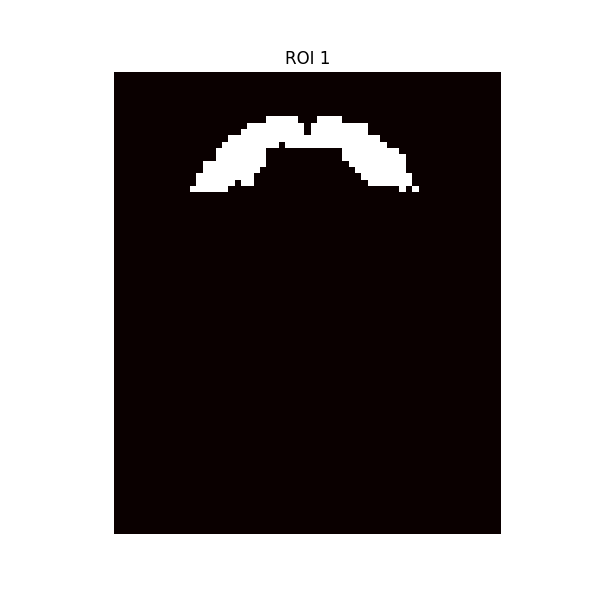

In [60]:
z = atlas_resampled_data.shape[2] // 2

plt.figure(figsize=(6,6))
plt.imshow(mask[:, :, z].T, cmap="hot", origin="lower")
plt.title(f"ROI {roi_id}")
plt.axis("off")
plt.show()

In [61]:
print("Nombre ROI:", atlas.labels[roi_id - 1])

Nombre ROI: Background


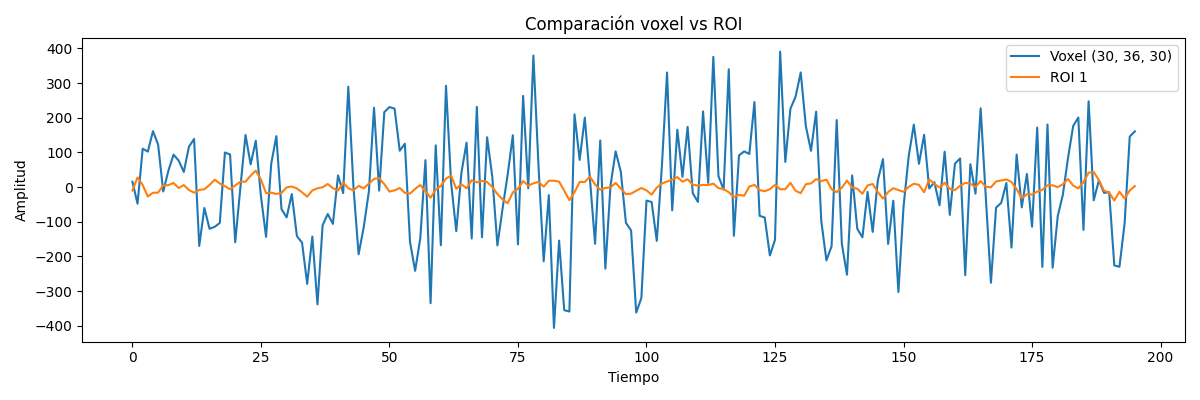

In [62]:
x = fmri_data.shape[0] // 2
y = fmri_data.shape[1] // 2
z_fmri = fmri_data.shape[2] // 2

voxel_signal = fmri_data[x, y, z_fmri, :]

plt.figure(figsize=(12, 4))
plt.plot(voxel_signal, label=f"Voxel ({x}, {y}, {z_fmri})")
plt.plot(roi_signal, label=f"ROI {roi_id}")
plt.title("Comparación voxel vs ROI")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
for roi_id in range(1, 11):
    mask = atlas_resampled_data == roi_id
    print(f"ROI {roi_id}: {np.sum(mask)} voxeles")

ROI 1: 4546 voxeles
ROI 2: 682 voxeles
ROI 3: 1509 voxeles
ROI 4: 1577 voxeles
ROI 5: 335 voxeles
ROI 6: 410 voxeles
ROI 7: 2546 voxeles
ROI 8: 1418 voxeles
ROI 9: 151 voxeles
ROI 10: 541 voxeles


## CONECTIVIDAD

In [65]:
%matplotlib widget

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

from nilearn import datasets
from nilearn.image import resample_to_img

In [67]:
abide = datasets.fetch_abide_pcp(
    data_dir="./data",
    n_subjects=1,
    pipeline="cpac",
    band_pass_filtering=False,
    global_signal_regression=False,
    derivatives=["func_preproc"]
)

fmri_path = abide.func_preproc[0]

fmri_img = nib.load(fmri_path)
fmri_data = fmri_img.get_fdata()

print("fMRI shape:", fmri_data.shape)

fMRI shape: (61, 73, 61, 196)


In [68]:
atlas_resampled = resample_to_img(
    atlas_img,
    fmri_img.slicer[:, :, :, 0],
    interpolation="nearest"
)

atlas_resampled_data = atlas_resampled.get_fdata()

print("Atlas remuestreado shape:", atlas_resampled_data.shape)

Atlas remuestreado shape: (61, 73, 61)


In [69]:
roi_ids = [int(i) for i in np.unique(atlas_resampled_data) if i != 0]

print("Primeros 20 ROI IDs:")
print(roi_ids[:20])
print("Cantidad total de ROIs:", len(roi_ids))

Primeros 20 ROI IDs:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Cantidad total de ROIs: 48


In [70]:
roi_sizes = {}

for roi_id in roi_ids:
    mask = atlas_resampled_data == roi_id
    roi_sizes[roi_id] = int(np.sum(mask))

print("Primeras 20 ROIs con tamaño:")
for roi_id in roi_ids[:20]:
    print(f"ROI {roi_id}: {roi_sizes[roi_id]} voxeles")

Primeras 20 ROIs con tamaño:
ROI 1: 4546 voxeles
ROI 2: 682 voxeles
ROI 3: 1509 voxeles
ROI 4: 1577 voxeles
ROI 5: 335 voxeles
ROI 6: 410 voxeles
ROI 7: 2546 voxeles
ROI 8: 1418 voxeles
ROI 9: 151 voxeles
ROI 10: 541 voxeles
ROI 11: 241 voxeles
ROI 12: 763 voxeles
ROI 13: 590 voxeles
ROI 14: 187 voxeles
ROI 15: 568 voxeles
ROI 16: 436 voxeles
ROI 17: 2024 voxeles
ROI 18: 866 voxeles
ROI 19: 498 voxeles
ROI 20: 709 voxeles


In [71]:
min_voxels = 100
selected_rois = [roi_id for roi_id in roi_ids if roi_sizes[roi_id] >= min_voxels]

print("Cantidad de ROIs seleccionadas:", len(selected_rois))
print("Primeras 20 seleccionadas:", selected_rois[:20])

Cantidad de ROIs seleccionadas: 47
Primeras 20 seleccionadas: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [72]:
roi_signals = []
roi_names = []

for roi_id in selected_rois:
    mask = atlas_resampled_data == roi_id
    signal = fmri_data[mask, :].mean(axis=0)
    roi_signals.append(signal)
    
    # nombre de la ROI
    if roi_id - 1 < len(atlas.labels):
        roi_names.append(str(atlas.labels[roi_id - 1]))
    else:
        roi_names.append(f"ROI_{roi_id}")

roi_signals = np.array(roi_signals).T   # tiempo x ROI

print("Shape matriz tiempo x ROI:", roi_signals.shape)

Shape matriz tiempo x ROI: (196, 47)


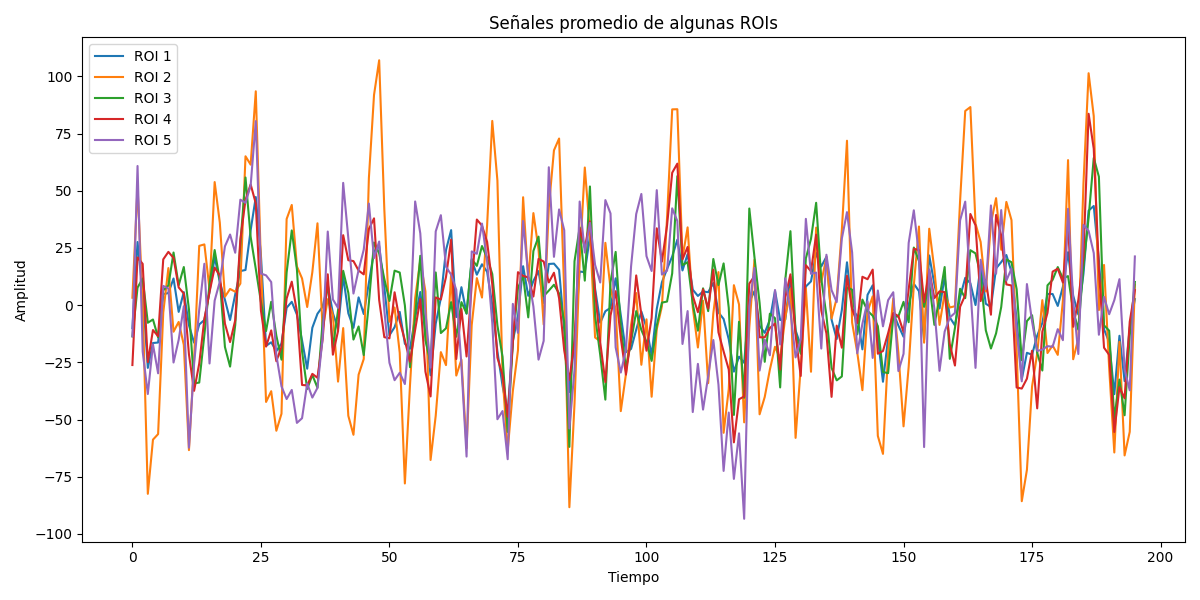

In [73]:
plt.figure(figsize=(12, 6))

for i in range(min(5, roi_signals.shape[1])):
    plt.plot(roi_signals[:, i], label=f"ROI {selected_rois[i]}")

plt.title("Señales promedio de algunas ROIs")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
corr_matrix = np.corrcoef(roi_signals.T)

print("Shape matriz ROI x ROI:", corr_matrix.shape)

Shape matriz ROI x ROI: (47, 47)


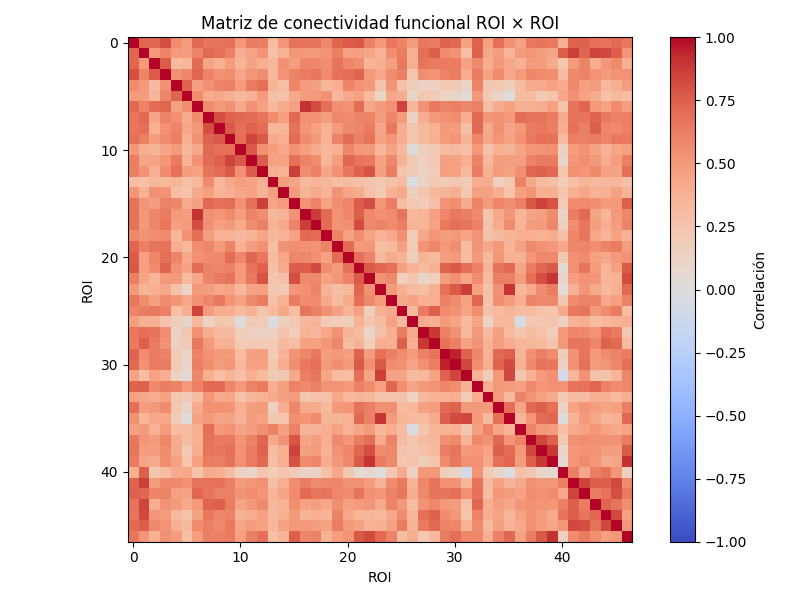

In [75]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlación")
plt.title("Matriz de conectividad funcional ROI × ROI")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.tight_layout()
plt.show()

In [76]:
print("Diagonal:")
print(np.diag(corr_matrix))

print("\nPrimer bloque 5x5:")
print(corr_matrix[:5, :5])

Diagonal:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Primer bloque 5x5:
[[1.         0.72608657 0.7256949  0.81124402 0.56011141]
 [0.72608657 1.         0.49773793 0.5963517  0.4964183 ]
 [0.7256949  0.49773793 1.         0.75911928 0.31375966]
 [0.81124402 0.5963517  0.75911928 1.         0.53675387]
 [0.56011141 0.4964183  0.31375966 0.53675387 1.        ]]


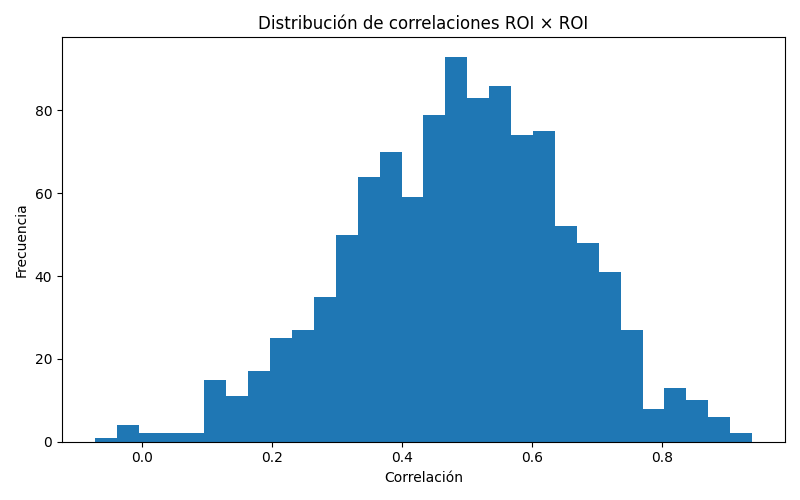

In [77]:
upper_tri = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]

plt.figure(figsize=(8, 5))
plt.hist(upper_tri, bins=30)
plt.title("Distribución de correlaciones ROI × ROI")
plt.xlabel("Correlación")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

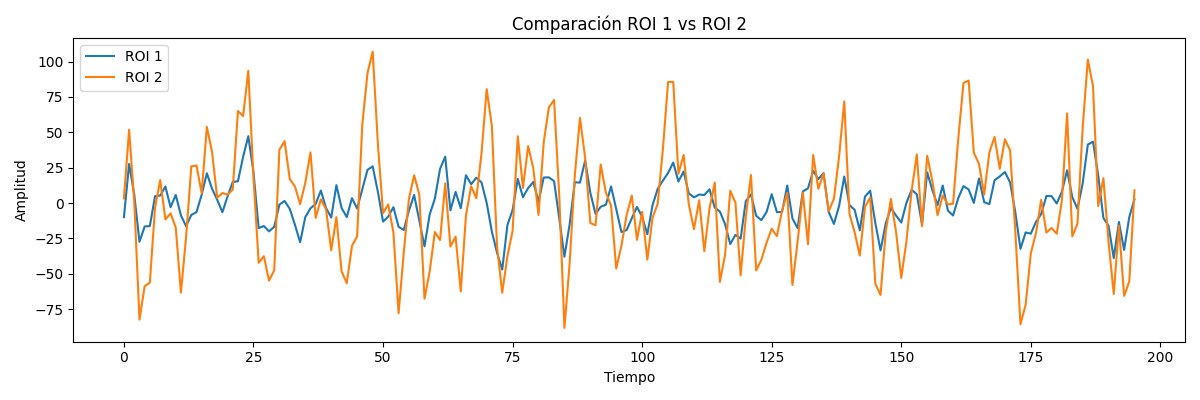

Correlación entre ROI 1 y ROI 2: 0.7261


In [78]:
i = 0
j = 1

plt.figure(figsize=(12, 4))
plt.plot(roi_signals[:, i], label=f"ROI {selected_rois[i]}")
plt.plot(roi_signals[:, j], label=f"ROI {selected_rois[j]}")
plt.title(f"Comparación ROI {selected_rois[i]} vs ROI {selected_rois[j]}")
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Correlación entre ROI {selected_rois[i]} y ROI {selected_rois[j]}: {corr_matrix[i, j]:.4f}")

In [79]:
import os

os.makedirs("resultados", exist_ok=True)

np.save("resultados/roi_signals.npy", roi_signals)
np.save("resultados/corr_matrix_roi.npy", corr_matrix)
np.save("resultados/selected_rois.npy", np.array(selected_rois))

print("Resultados guardados.")

Resultados guardados.
